In [1]:
import pandas as pd

import numpy as np
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
import seaborn as sns

from arch import arch_model

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout,Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



from typing import List, Tuple

sns.set_style("whitegrid")

c:\Users\yahya\Desktop\MR Project\Code\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
def create_sequences(
    data: pd.DataFrame,
    lookback: int,
    horizon: int,
    feature_cols: List[str],
    predict_cols: List[str],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create input-output sequences for time series forecasting.

    Parameters
    ----------
    data : pd.DataFrame
        Time-ordered dataframe.
    lookback : int
        Number of past timesteps used as input.
    horizon : int
        Number of future timesteps to predict.
    feature_cols : list of str
        Columns used as model inputs.
    predict_cols : list of str
        Columns used as prediction targets.

    Returns
    -------
    X : np.ndarray
        Shape (n_samples, lookback, n_features)
    y : np.ndarray
        Shape (n_samples, horizon, n_targets)
    """

    if lookback <= 0 or horizon <= 0:
        raise ValueError("lookback and horizon must be positive integers")

    missing_features = set(feature_cols) - set(data.columns)
    missing_targets = set(predict_cols) - set(data.columns)
    if missing_features or missing_targets:
        raise ValueError(
            f"Missing columns - features: {missing_features}, targets: {missing_targets}"
        )

    values_X = data[feature_cols].values
    values_y = data[predict_cols].values

    X, y = [], []

    max_start = len(data) - lookback - horizon
    for i in range(max_start):
        X.append(values_X[i : i + lookback])
        y.append(values_y[i + lookback : i + lookback + horizon])

    return np.array(X, dtype=np.float64), np.array(y, dtype=np.float64)

In [3]:
def q_like(realized, predicted):
    div = realized/predicted
    ql = div - np.log(div) - 1
    return np.mean(ql)

In [4]:
data = pd.read_csv(r'../Data/dataset/spy_1min_2008_2021_cleaned.csv', parse_dates=['date'], index_col='date')

## Features Engineering

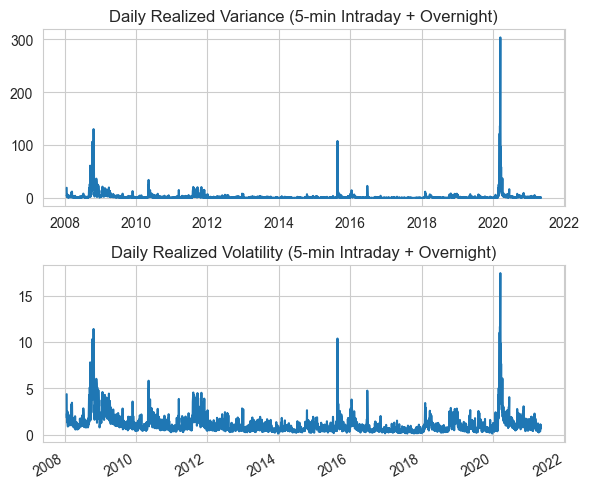

In [5]:

# Intraday Variance
close_5mn = data.close.resample("5min").last().dropna()
rt_intraday = np.log(close_5mn / close_5mn.shift(1)).dropna()
rv_intraday = (rt_intraday ** 2).groupby(rt_intraday.index.date).sum()

# Overnight Variance
daily_ohlc = data.close.resample("1D").agg(['first', 'last']).dropna()
daily_ohlc["prev_close"] = daily_ohlc['last'].shift(1)

# Overnight returns
rt_overnight = np.log(daily_ohlc['first'] / daily_ohlc['prev_close']).dropna()
rv_overnight = rt_overnight ** 2

# Total Realized Variance
rv_total = pd.DataFrame({'intraday': rv_intraday, 'overnight': rv_overnight}).dropna()
rv_total['RV_Daily_Var'] = rv_total['intraday'] + rv_total['overnight']

# Scale to match GARCH (x100^2 = x10000)
target_variance = rv_total['RV_Daily_Var'] * 10000
target_volatility = np.sqrt(target_variance)
target_volatility.index = pd.to_datetime(target_volatility.index)
target_volatility.name = 'RV_Daily_Vol'


fig, ax = plt.subplots(2, 1, figsize=(6,5))
target_variance.plot(title="Daily Realized Variance (5-min Intraday + Overnight)", ax=ax[0])
target_volatility.plot(title="Daily Realized Volatility (5-min Intraday + Overnight)", ax=ax[1])
plt.tight_layout()
plt.show()

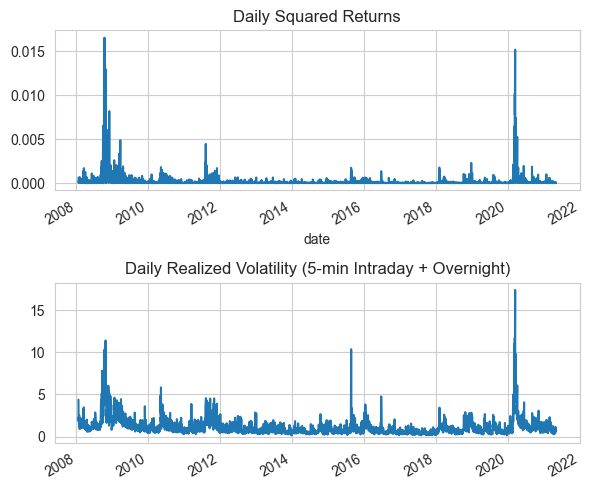

In [6]:
df_daily_close = data.close.resample("1D").last().dropna()
r_daily = np.log(df_daily_close / df_daily_close.shift(1)).dropna()
r_daily.name = "Daily_Return"
r2_daily = r_daily ** 2
r2_daily.name = "Daily_Squared_Return"

fig, ax = plt.subplots(2, 1, figsize=(6,5))
r2_daily.plot(title="Daily Squared Returns", ax=ax[0])
target_volatility.plot(title="Daily Realized Volatility (5-min Intraday + Overnight)", ax=ax[1])
plt.tight_layout()
plt.show()

## Analysis

### Stationarity Test

In [7]:
adfuller_result = adfuller(r_daily)
print("ADF Statistic:", adfuller_result[0])
print("p-value:", adfuller_result[1])
print("Critical Values:")
for key, value in adfuller_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -14.315982130207596
p-value: 1.1627203853193956e-26
Critical Values:
   1%: -3.4323164516352445
   5%: -2.8624088629359186
   10%: -2.5672325132363225


### Auto-correlation and Partial Auto-correlation Analysis

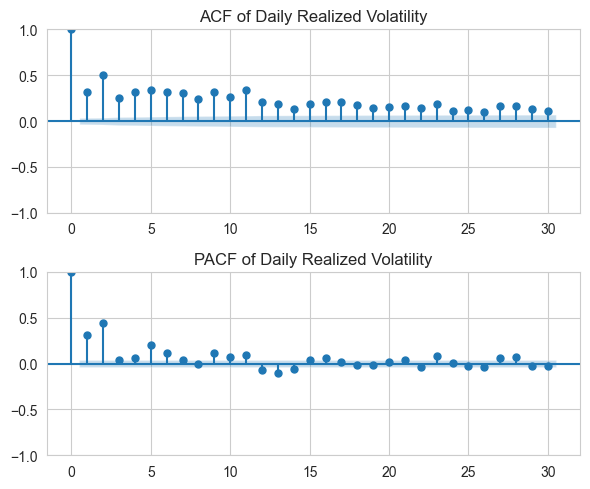

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(6,5))
plot_acf(r2_daily, lags=30, ax=ax[0], title="ACF of Daily Realized Volatility")
plot_pacf(r2_daily, lags=30, ax=ax[1], title="PACF of Daily Realized Volatility")
plt.tight_layout()
plt.show()

### Distribution Analysis

<Axes: title={'center': 'Daily Log Returns'}, ylabel='Frequency'>

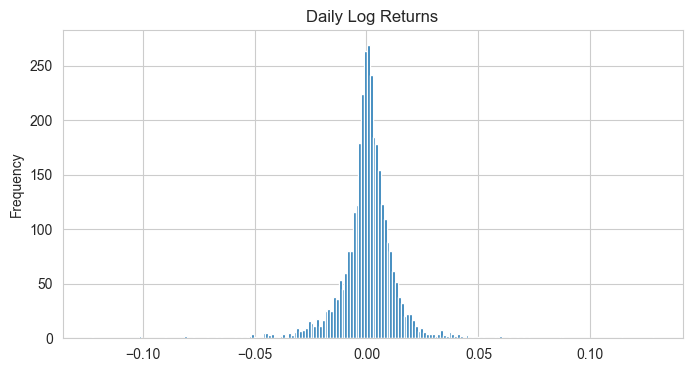

In [9]:
r_daily.plot(title="Daily Log Returns", figsize=(8,4), kind='hist', bins=200)

Distribution parameters:  (np.float64(2.098809399123282), np.float64(0.0009018168160810856), np.float64(0.006305716335320519))


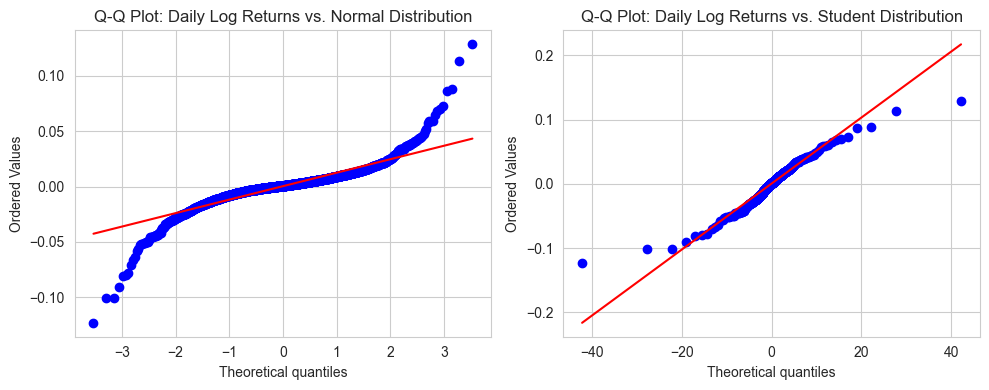

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

params = stats.t.fit(r_daily)
print("Distribution parameters: ",params)

stats.probplot(r_daily, dist="norm", plot=ax[0])
ax[0].set_title("Q-Q Plot: Daily Log Returns vs. Normal Distribution")


stats.probplot(r_daily, dist="t",sparams=(params[0],), plot=ax[1])
ax[1].set_title("Q-Q Plot: Daily Log Returns vs. Student Distribution")

plt.tight_layout()
plt.show()

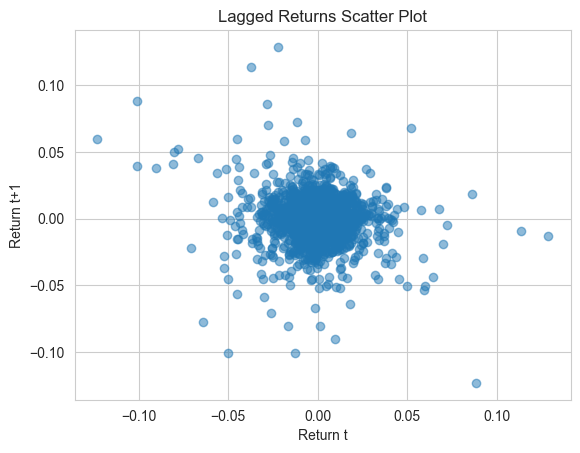

In [11]:
n = 1
plt.plot(r_daily[:-n][:], r_daily[n:][:], 'o', alpha=0.5,)
plt.xlabel('Return t')
plt.ylabel(f'Return t+{n}')
plt.title('Lagged Returns Scatter Plot')
plt.show()

## Data preparation

In [12]:
ration = .9
split_index = int(len(r_daily) * ration)
split_date = r_daily.index[split_index]
print("Train/Test Split Date:", split_date)

Train/Test Split Date: 2020-01-08 00:00:00


## GARCH

In [13]:
model = arch_model(r_daily * 100, vol='Garch', p=1, q=1, dist='t',)
res = model.fit(last_obs=split_date, disp='off')
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                 Daily_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3882.67
Distribution:      Standardized Student's t   AIC:                           7775.34
Method:                  Maximum Likelihood   BIC:                           7805.39
                                              No. Observations:                 3011
Date:                      Wed, Jan 28 2026   Df Residuals:                     3010
Time:                              15:47:18   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0864  1.175e-02      7.350  1.987e-13 [6.333e-02,  0.109]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0169  4.562e-03      3.705  2.116e-04 [7.959e-03,2.584e-02]
alpha[1]       0.1544  2.024e-02      7.629  2.361e-14     [  0.115,  0.194]
beta[1]        0.8456  1.758e-02     48.107      0.000     [  0.811,  0.880]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.1194      0.481     10.638  1.974e-26 [  4.176,  6.063]
========================================================================

Covariance estimator: robust
"""

In [14]:
forecast_horizon = res.forecast(start=r_daily.index[0],)
garch_var = forecast_horizon.variance.dropna()
garch_var.columns = ['GARCH_Variance_Forecast']
garch_var.head()

,GARCH_Variance_Forecast
date,
2008-01-23,2.555493
2008-01-24,2.240112
2008-01-25,2.250282
2008-01-28,2.281855
2008-01-29,1.974008


In [15]:
test_target_var = pd.DataFrame(target_variance.loc[garch_var.index])
test_target_var.columns = ['Variance_Target']
print(test_target_var.head())

            Variance_Target
date                       
2008-01-23        19.220556
2008-01-24         3.350233
2008-01-25         5.258443
2008-01-28         2.371099
2008-01-29         1.840102


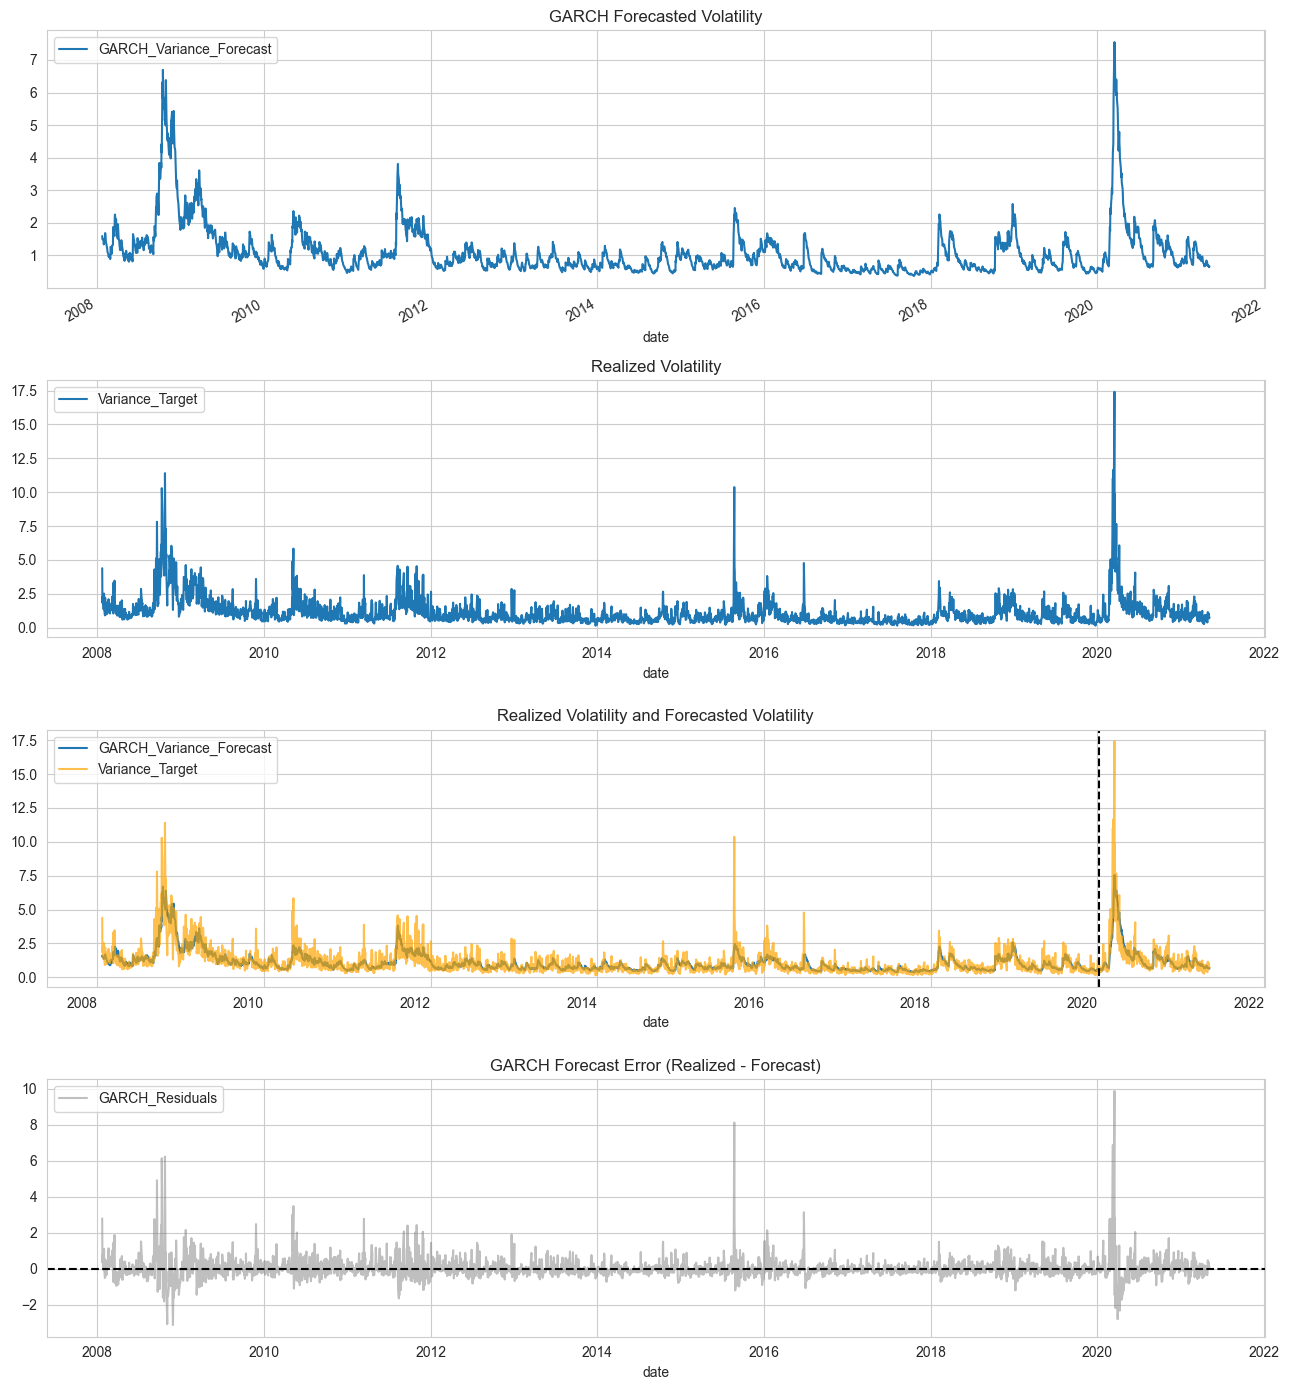

In [16]:
fig, ax = plt.subplots(4, 1, figsize=(13, 14))

np.sqrt(garch_var).plot(title="GARCH Forecasted Volatility", ax=ax[0])

np.sqrt(test_target_var).plot(title="Realized Volatility", ax=ax[1])

np.sqrt(garch_var).plot(title="Realized Volatility and Forecasted Volatility", ax=ax[2])
np.sqrt(test_target_var).plot(ax=ax[2], color='orange', alpha=0.7)
ax[2].axvline(split_date, color='black', linestyle='--')


residuals = np.sqrt(test_target_var["Variance_Target"]) - np.sqrt(garch_var['GARCH_Variance_Forecast'])
residuals.name = "GARCH_Residuals"
residuals.plot(color='gray', alpha=0.5, ax=ax[3])
ax[3].axhline(0, color='black', linestyle='--')
ax[3].set_title("GARCH Forecast Error (Realized - Forecast)")

plt.legend()
plt.tight_layout()
plt.show()

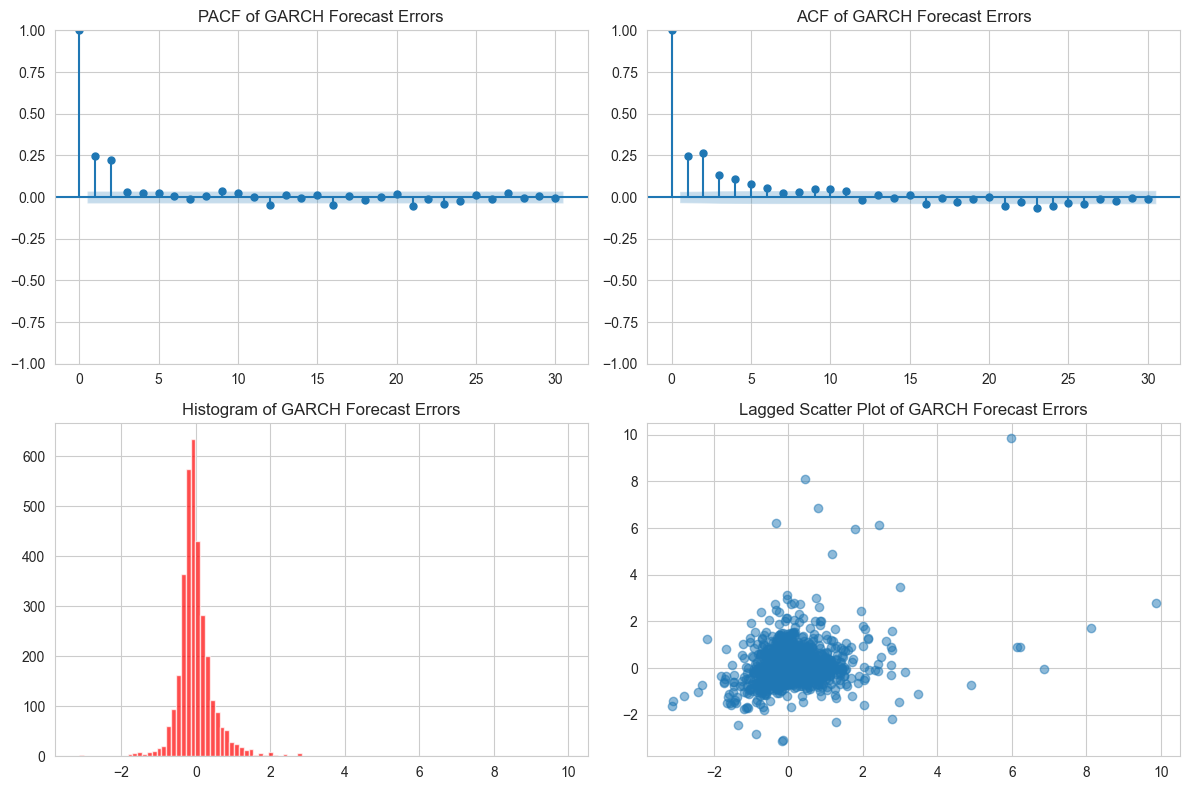

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
plot_pacf(residuals, lags=30, title="PACF of GARCH Forecast Errors", ax=ax[0, 0])
plot_acf(residuals, lags=30, title="ACF of GARCH Forecast Errors", ax=ax[0, 1])

residuals.hist(bins=100, color='red', alpha=0.7, ax=ax[1, 0])
ax[1, 0].set_title("Histogram of GARCH Forecast Errors")

ax[1, 1].scatter(residuals[:-2], residuals[2:], alpha=0.5)
ax[1, 1].set_title("Lagged Scatter Plot of GARCH Forecast Errors")

plt.tight_layout()
plt.show()

In [18]:
print("Evaluation Metrics Naive Model:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var[r_daily.index > split_date]).iloc[1:], np.sqrt(test_target_var[r_daily.index > split_date]).shift(1).dropna()))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var[r_daily.index > split_date]).iloc[1:], np.sqrt(test_target_var[r_daily.index > split_date]).shift(1).dropna()))
print("     QLIKE:", q_like((test_target_var[r_daily.index > split_date]).iloc[1:].to_numpy(), (test_target_var[r_daily.index > split_date]).shift(1).dropna().to_numpy()))

print("Evaluation Metrics:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var[r_daily.index > split_date]["Variance_Target"]), np.sqrt(garch_var[r_daily.index > split_date]["GARCH_Variance_Forecast"])))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var[r_daily.index > split_date]["Variance_Target"]), np.sqrt(garch_var[r_daily.index > split_date]["GARCH_Variance_Forecast"])))
print("     QLIKE:", q_like((test_target_var[r_daily.index > split_date]["Variance_Target"]).to_numpy(), (garch_var[r_daily.index > split_date]["GARCH_Variance_Forecast"]).to_numpy()))

Evaluation Metrics Naive Model:
     MAE: 0.6315790850908144
     MSE: 1.5831874600642553
     QLIKE: 0.5064822554176154
Evaluation Metrics:
     MAE: 0.5067891743795462
     MSE: 1.001419247285357
     QLIKE: 0.3181014531513183


In [19]:
gru_entry = pd.DataFrame(residuals)
gru_entry["Daily_Return"] = r_daily
gru_entry.head()

,GARCH_Residuals,Daily_Return
date,,
2008-01-23,2.785535,0.025098
2008-01-24,0.333664,0.007215
2008-01-25,0.793036,-0.013957
2008-01-28,0.029256,0.016178
2008-01-29,-0.048491,0.005090


In [20]:
HORIZON = 1
LOOKBACK = 10
feature_cols = ["GARCH_Residuals","Daily_Return"]
predict_cols = ["GARCH_Residuals",]

X_raw, y_raw = create_sequences(
    data=gru_entry,
    lookback=LOOKBACK,
    horizon=HORIZON,
    feature_cols=feature_cols,
    predict_cols=predict_cols,
)


print(f"X shape: {X_raw.shape}  (Samples, Timesteps, Features)")
print(f"y shape: {y_raw.shape}  (Samples, Horizon)")

X shape: (3335, 10, 2)  (Samples, Timesteps, Features)
y shape: (3335, 1, 1)  (Samples, Horizon)


In [21]:
ratio = .9
n_sep = int(ratio * X_raw.shape[0])

X_train, X_test = X_raw[:n_sep], X_raw[n_sep:]
y_train, y_test = y_raw[:n_sep], y_raw[n_sep:]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_scaled = X_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, y_train.shape[-1])
).reshape(y_train.shape)

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, y_test.shape[-1])
).reshape(y_test.shape)

print("Data shapes:")
print("Raw Data:")
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

print("Scaled Data:")
print(f"Training set: X={X_train_scaled.shape}, y={y_train_scaled.shape}")
print(f"Test set: X={X_test_scaled.shape}, y={y_test_scaled.shape}")

Data shapes:
Raw Data:
Training set: X=(3001, 10, 2), y=(3001, 1, 1)
Test set: X=(334, 10, 2), y=(334, 1, 1)
Scaled Data:
Training set: X=(3001, 10, 2), y=(3001, 1, 1)
Test set: X=(334, 10, 2), y=(334, 1, 1)


In [22]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])
OUTPUT_SIZE = y_train.shape[1]

print(f"Input shape: {INPUT_SHAPE}")
print(f"Output size: {OUTPUT_SIZE}")

Input shape: (10, 2)
Output size: 1


In [23]:
model = Sequential(
    [
        Input(shape=INPUT_SHAPE),
        GRU(units=64, return_sequences=False, activation="tanh", recurrent_dropout=0.0),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(OUTPUT_SIZE, activation="linear"),
    ]
)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,169 (59.25 KB)

 Trainable params: 15,169 (59.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.8916 - mae: 0.5773 - val_loss: 3.1275 - val_mae: 0.8625 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8497 - mae: 0.5638 - val_loss: 3.2782 - val_mae: 0.8641 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8368 - mae: 0.5635 - val_loss: 3.2937 - val_mae: 0.8623 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8239 - mae: 0.5608 - val_loss: 3.1802 - val_mae: 0.8595 - learning_rate: 0.0010
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8152 - mae: 0.5580 - val_loss: 3.2082 - val_mae: 0.8550 - learning_rate: 0.0010
Epoch 6/100
91/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9225 - mae: 0.5847
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8108 - mae: 0.5567 - val_loss: 3.2834 - val_mae: 0.8520 - learning_rate: 0.0010
Epoch 7/1

In [25]:
y_pred_scaled: np.ndarray = model.predict(X_test_scaled)


y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_pred_scaled.shape)

y_true = y_scaler.inverse_transform(
    y_test_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_test_scaled.shape)

pred_label = "Predicted_Variance"
true_label = "Actual_Variance"

y_pred_df = pd.DataFrame(
    (y_pred)[:, 0], index=r_daily.index[LOOKBACK + n_sep : -HORIZON], columns=[pred_label]
)
y_true_df = pd.DataFrame(
    (y_true)[:, 0], index=r_daily.index[LOOKBACK + n_sep : -HORIZON], columns=[true_label]
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


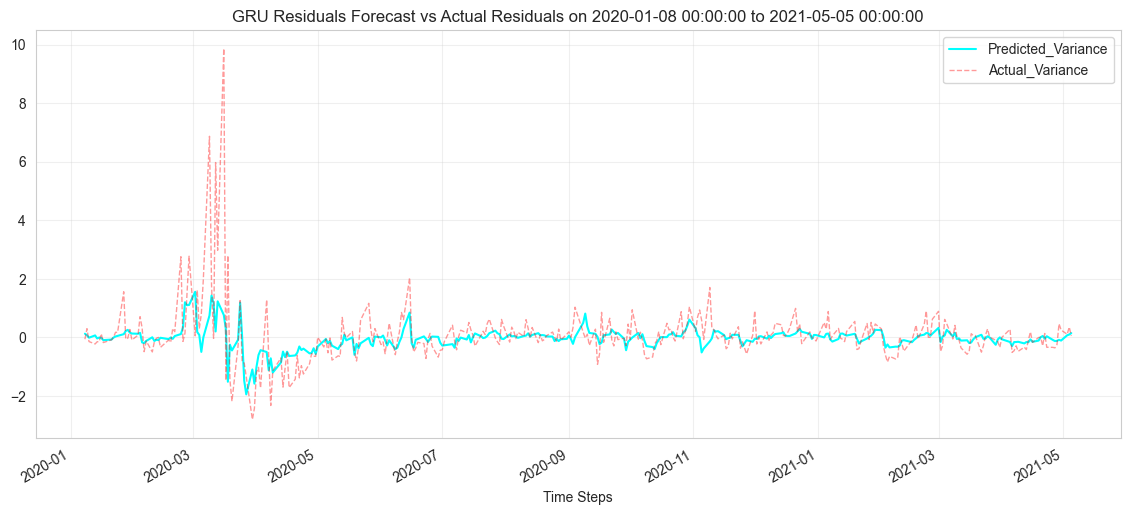

In [26]:
fig, ax = plt.subplots( figsize=(14, 6))
y_pred_df.plot(ax=ax, color="cyan", legend=True)
y_true_df.plot(ax=ax, color="red", linewidth=1, linestyle="--", legend=True, alpha=0.4)

plt.title(
    f"GRU Residuals Forecast vs Actual Residuals on {y_pred_df.index[0]} to {y_pred_df.index[-1]}"
)
plt.xlabel("Time Steps")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
vol_res_back = np.sqrt(garch_var[(r_daily.index >= y_pred_df.index[0]) & (r_daily.index <= y_pred_df.index[-1])]["GARCH_Variance_Forecast"]).values + y_pred_df.values.ravel()
# vol_res_back

In [28]:
real_vol_target = np.sqrt(test_target_var[(r_daily.index >= y_pred_df.index[0]) & (r_daily.index <= y_pred_df.index[-1])]["Variance_Target"])
# real_vol_target

In [49]:
fin_df = pd.DataFrame(
    {
        "Hybrid_Volatility_Forecast": vol_res_back,
        "Realized_Volatility": real_vol_target.values,
        "Garch_volatility_Forecast": np.sqrt(garch_var[(r_daily.index >= y_pred_df.index[0]) & (r_daily.index <= y_pred_df.index[-1])]["GARCH_Variance_Forecast"]).values,
    },
    index=real_vol_target.index,
)

fin_df.head()

,Hybrid_Volatility_Forecast,Realized_Volatility,Garch_volatility_Forecast
date,,,
2020-01-08,0.703219,0.514477,0.581589
2020-01-09,0.663660,0.890931,0.597607
2020-01-10,0.567920,0.435188,0.582967
2020-01-13,0.663295,0.371226,0.600679
2020-01-14,0.534107,0.421070,0.575367


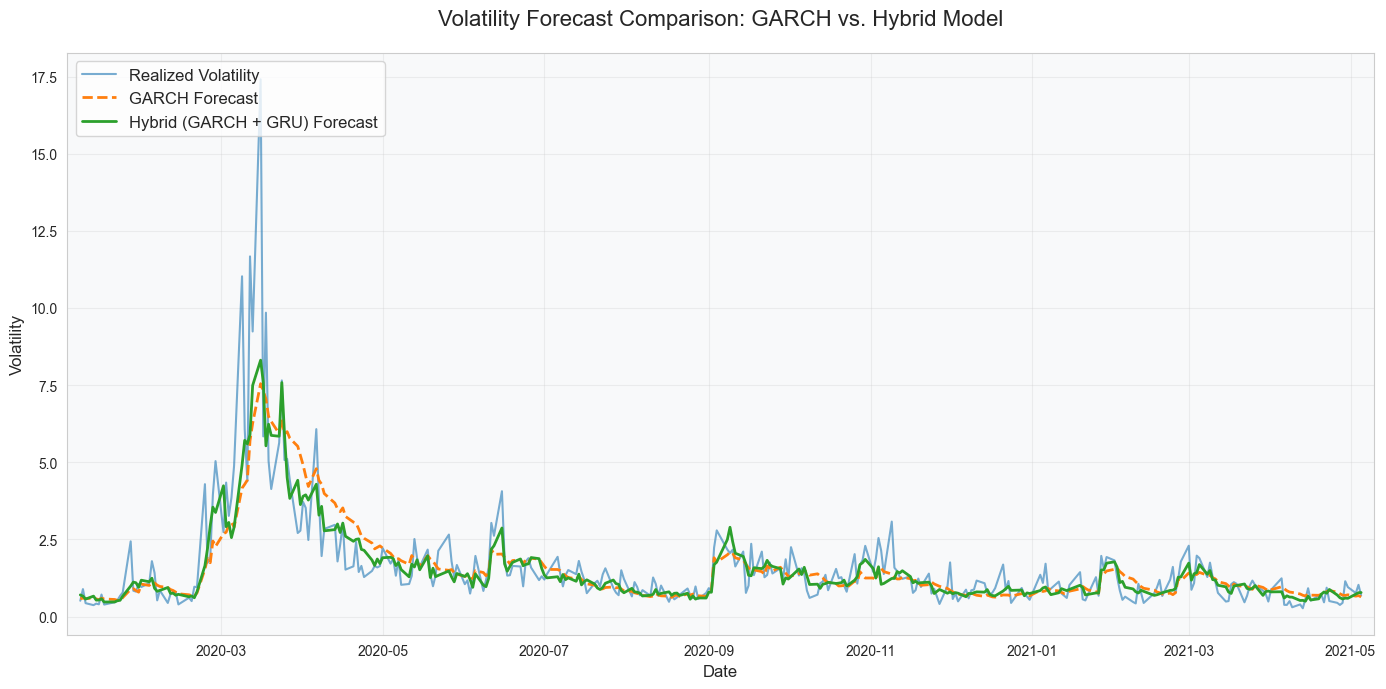

In [58]:
# Create a professional plot for the volatility forecasts
plt.figure(figsize=(14, 7))

# Plot Realized Volatility
plt.plot(fin_df.index, fin_df['Realized_Volatility'], 
         label='Realized Volatility', color='#1f77b4', alpha=0.6, linewidth=1.5)

# Plot GARCH Forecast
plt.plot(fin_df.index, fin_df['Garch_volatility_Forecast'], 
         label='GARCH Forecast', color='#ff7f0e', linestyle='--', linewidth=2)

# Plot Hybrid Forecast
plt.plot(fin_df.index, fin_df['Hybrid_Volatility_Forecast'], 
         label='Hybrid (GARCH + GRU) Forecast', color='#2ca02c', linewidth=2)

# Formatting
plt.title('Volatility Forecast Comparison: GARCH vs. Hybrid Model', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volatility', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.margins(x=0.01)

# Add a subtle background color for better readability
plt.gca().set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

In [57]:
print("Evaluation Metrics Naive Model:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var[r_daily.index > split_date]).iloc[1:], np.sqrt(test_target_var[r_daily.index > split_date]).shift(1).dropna()))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var[r_daily.index > split_date]).iloc[1:], np.sqrt(test_target_var[r_daily.index > split_date]).shift(1).dropna()))
print("     QLIKE:", q_like((test_target_var[r_daily.index > split_date]).iloc[1:].to_numpy(), (test_target_var[r_daily.index > split_date]).shift(1).dropna().to_numpy()))

print("Evaluation Metrics:")
print("     MAE:", mean_absolute_error(np.sqrt(test_target_var[r_daily.index > split_date]["Variance_Target"]), np.sqrt(garch_var[r_daily.index > split_date]["GARCH_Variance_Forecast"])))
print("     MSE:", mean_squared_error(np.sqrt(test_target_var[r_daily.index > split_date]["Variance_Target"]), np.sqrt(garch_var[r_daily.index > split_date]["GARCH_Variance_Forecast"])))
print("     QLIKE:", q_like((test_target_var[r_daily.index > split_date]["Variance_Target"]).to_numpy(), (garch_var[r_daily.index > split_date]["GARCH_Variance_Forecast"]).to_numpy()))

print("Evaluation Metrics on GARCH alone + GRU Residuals:")
print("     MAE:", mean_absolute_error(vol_res_back, real_vol_target))
print("     MSE:", mean_squared_error(vol_res_back, real_vol_target))
print("     QLIKE:", q_like(vol_res_back**2, real_vol_target**2))

Evaluation Metrics Naive Model:
     MAE: 0.6315790850908144
     MSE: 1.5831874600642553
     QLIKE: 0.5064822554176154
Evaluation Metrics:
     MAE: 0.5067891743795462
     MSE: 1.001419247285357
     QLIKE: 0.3181014531513183
Evaluation Metrics on GARCH alone + GRU Residuals:
     MAE: 0.4368969736850381
     MSE: 0.7992735085921537
     QLIKE: 0.2510890752851056


In [30]:

# Student, W = 10, SPLIT 90/10, FEATURES: GARCH RESIDUALS + DAILY RETURN
# Evaluation Metrics Naive Model:
#      MAE: 0.6315790850908144
#      MSE: 1.5831874600642553
#      QLIKE: 0.5064822554176154
# Evaluation Metrics:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH alone + GRU Residuals:
#      MAE: 0.43571910836981853
#      MSE: 0.8331072910354034
#      QLIKE: 0.24899200169346422

## ONLY ONE FEATURE GRU (RESIDUALS)
# STUDENT, W = 10, SPLIT 90/10
# Evaluation Metrics Naive Model:
#      MAE: 0.6315790850908144
#      MSE: 1.5831874600642553
#      QLIKE: 0.5064822554176154
# Evaluation Metrics:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH alone + GRU Residuals:
#      MAE: 0.4626851659063404
#      MSE: 0.8435887348856335
#      QLIKE: 0.3041789290151227
     
# STUDENT, W = 20, SPLIT 90/10
# Evaluation Metrics Naive Model:
#      MAE: 0.6315790850908144
#      MSE: 1.5831874600642553
#      QLIKE: 0.5064822554176154
# Evaluation Metrics:
#      MAE: 0.5067891743795462
#      MSE: 1.001419247285357
#      QLIKE: 0.3181014531513183
# Evaluation Metrics on GARCH alone + GRU Residuals:
#      MAE: 0.46746136401004834
#      MSE: 0.8149615512470919
#      QLIKE: 0.30757352814465655

# GAUSSIAN, W = 20, SPLIT 90/10
# Evaluation Metrics Naive Model:
#      MAE: 0.6315790850908144
#      MSE: 1.5831874600642553
#      QLIKE: 0.5064822554176154
# Evaluation Metrics:
#      MAE: 0.48756717368098396
#      MSE: 0.9824804599287948
#      QLIKE: 0.32638104744444435
# Evaluation Metrics on GARCH alone + GRU Residuals:
#      MAE: 0.4647022508139141
#      MSE: 0.8006221147267334
#      QLIKE: 0.3227423770250897